This notebook is responsible for evaluating and comparing the best models as validated and fine-tuned in previous notebooks. Comparisons are made between the three model families:
- Across all five feature sets using RMSE.
- With a full feature set using a weighted RMSE on top quartile demand hours.

# Library Dependencies

In [1]:
#!pip install -qq joblib ipython numpy pandas scikit-learn torch

In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import root_mean_squared_error


In [3]:
!python --version
print("numpy", np.__version__)
print("pandas", pd.__version__)
print("torch", torch.__version__)

Python 3.10.18
numpy 2.2.6
pandas 2.3.3
torch 2.9.1


# Data and Model Loading, Evaluation Preparation

In [4]:
MODEL_NAMES = ["model_A", "model_B", "model_C", "model_D", "model_E", "model_F"]
TARGET_COL = "Adjusted demand"

data_root = Path("data/clean")
test_dir  = data_root / "test"
fig_root = Path("figures")
fig_root.mkdir(parents=True, exist_ok=True)

# Model root paths
arx_root  = Path("models") / "ARX_Ridge"
xgb_root  = Path("models") / "XGB"
lstm_root = Path("models") / "LSTM"

DFtest = pd.read_pickle(test_dir / "DFtest.pkl")
print("n_test:", len(DFtest))

test_block_paths = sorted(test_dir.glob("DFtest_block*.pkl"))
print("Test blocks:", len(test_block_paths))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Container for RMSEs: rmse_results[family][model_name]
rmse_results = {
    "ARX_Ridge": {},
    "XGB": {},
    "LSTM": {},
}


n_test: 12782
Test blocks: 41
Using device: cpu


# Model Testing

In [5]:
# ARX-Ridge Models

for name in MODEL_NAMES:
    
    meta_path = arx_root / f"{name}_ridge_meta.json"
    model_path = arx_root / f"{name}_ridge_best.joblib"

    print(f"\n[ARX] Loading {name}")
    with open(meta_path, "r") as f:
        meta = json.load(f)

    feature_cols = meta["feature_cols"]
    target_col   = meta.get("target_col", TARGET_COL)

    arx_model = joblib.load(model_path)

    X_test = DFtest[feature_cols]
    y_test = DFtest[target_col].to_numpy()

    y_pred = arx_model.predict(X_test)

    peak_cfg = meta.get("peak_weighting", None)

    if peak_cfg is not None:
        q75  = peak_cfg["threshold"]
        peak_weight = peak_cfg["peak_weight"]
        peak_mask_test = DFtest[target_col] >= q75
        w_test = np.where(peak_mask_test.to_numpy(), peak_weight, 1.0)
        rmse_unweighted = root_mean_squared_error(y_test, y_pred)
        rmse_weighted = root_mean_squared_error(y_test, y_pred, sample_weight=w_test)
        rmse_results["ARX_Ridge"][name] = rmse_weighted
        print(f"[ARX] {name}: Test RMSE (unweighted)    = {rmse_unweighted:.4f}")
        print(f"[ARX] {name}: Test RMSE (peak-weighted) = {rmse_weighted:.4f}")
    else:
        rmse = root_mean_squared_error(y_test, y_pred)
        rmse_results["ARX_Ridge"][name] = rmse
        print(f"[ARX] {name}: Test RMSE = {rmse:.4f}")



[ARX] Loading model_A
[ARX] model_A: Test RMSE = 480.5179

[ARX] Loading model_B
[ARX] model_B: Test RMSE = 480.3032

[ARX] Loading model_C
[ARX] model_C: Test RMSE = 457.4341

[ARX] Loading model_D
[ARX] model_D: Test RMSE = 454.9531

[ARX] Loading model_E
[ARX] model_E: Test RMSE = 584.7810

[ARX] Loading model_F
[ARX] model_F: Test RMSE (unweighted)    = 461.7288
[ARX] model_F: Test RMSE (peak-weighted) = 459.1189


In [6]:
# XGB GBM Models

for name in MODEL_NAMES:
    
    meta_path = xgb_root / f"{name}_XGB_meta.json"
    model_path = xgb_root / f"{name}_XGB_best.joblib"

    print(f"\n[XGB] Loading {name}")
    with open(meta_path, "r") as f:
        meta = json.load(f)

    feature_cols = meta["feature_cols"]
    target_col   = meta.get("target_col", TARGET_COL)

    xgb_model = joblib.load(model_path)

    X_test = DFtest[feature_cols].to_numpy()
    y_test = DFtest[target_col].to_numpy()

    y_pred = xgb_model.predict(X_test)

    peak_cfg = meta.get("peak_weighting", None)

    if peak_cfg is not None:
        q75 = peak_cfg["threshold"]
        peak_weight = peak_cfg["peak_weight"]
        peak_mask_test = DFtest[target_col] >= q75
        w_test = np.where(peak_mask_test.to_numpy(), peak_weight, 1.0)
        rmse_unweighted = root_mean_squared_error(y_test, y_pred)
        rmse_weighted = root_mean_squared_error(y_test, y_pred, sample_weight=w_test)
        rmse_results["XGB"][name] = rmse_weighted
        print(f"[XGB] {name}: Test RMSE (unweighted)    = {rmse_unweighted:.4f}")
        print(f"[XGB] {name}: Test RMSE (peak-weighted) = {rmse_weighted:.4f}")
    else:
        rmse = root_mean_squared_error(y_test, y_pred)
        rmse_results["XGB"][name] = rmse
        print(f"[XGB] {name}: Test RMSE = {rmse:.4f}")



[XGB] Loading model_A
[XGB] model_A: Test RMSE = 537.0736

[XGB] Loading model_B
[XGB] model_B: Test RMSE = 522.3901

[XGB] Loading model_C
[XGB] model_C: Test RMSE = 519.3770

[XGB] Loading model_D
[XGB] model_D: Test RMSE = 540.7051

[XGB] Loading model_E
[XGB] model_E: Test RMSE = 903.4777

[XGB] Loading model_F
[XGB] model_F: Test RMSE (unweighted)    = 503.7902
[XGB] model_F: Test RMSE (peak-weighted) = 553.5403


In [7]:
# LSTM evaluation

def make_seq(X, y, seq_len):
    """
    Build overlapping (sequence, target) pairs from one continuous block.
    X: (N, num_features), y: (N,)
    returns:
      X_seq: (N - seq_len, seq_len, num_features)
      y_seq: (N - seq_len,)
    """
    
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32).reshape(-1)

    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i : i + seq_len])
        ys.append(y[i + seq_len])

    if not Xs:
        return None, None

    return torch.tensor(np.stack(Xs)), torch.tensor(np.array(ys))


def make_seq_from_blocks(block_paths, seq_len, df_to_scaled_arrays_fn):
    """
    For a list of block .pkl files, build sequences per block and concatenate.
    Skips blocks that are too short for at least one full sequence.
    df_to_scaled_arrays_fn: function mapping df -> (X_s, y_s)
    """
    
    X_seq_list = []
    y_seq_list = []

    for path in block_paths:
        df_block = pd.read_pickle(path)

        if len(df_block) <= seq_len:
            # too short for one sequence
            continue

        X_s, y_s = df_to_scaled_arrays_fn(df_block)
        X_block, y_block = make_seq(X_s, y_s, seq_len)

        if X_block is None:
            continue

        X_seq_list.append(X_block)
        y_seq_list.append(y_block)

    if not X_seq_list:
        raise ValueError(
            f"No blocks produced sequences; ensure some blocks have length > seq_len={seq_len}."
        )

    X_seq_all = torch.cat(X_seq_list, dim=0)
    y_seq_all = torch.cat(y_seq_list, dim=0)
    return X_seq_all, y_seq_all


class LSTMRegressor(nn.Module):
    """
    LSTM-based regressor that maps a sequence of feature vectors
    to a single scalar prediction (next-hour demand).
    """
    
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_hidden = lstm_out[:, -1, :] 
        output = self.fc(last_hidden)
        return output.squeeze(-1)


def eval_lstm_on_test(model_name):
    """
    Load best LSTM for model_name (full model object),
    build test sequences using its saved scalers + features,
    and compute test RMSE in original units.

    For model_F (which has 'peak_weighting' saved), returns peak-weighted
    test RMSE; for others, returns unweighted RMSE.
    """
    
    ckpt_path = lstm_root / f"{model_name}_LSTM_best.pt"
    print(f"\n[LSTM] Loading {model_name} from {ckpt_path}")

    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)

    model        = ckpt["model"].to(device)
    feature_cols = ckpt["feature_cols"]
    x_scaler     = ckpt["x_scaler"]
    y_scaler     = ckpt["y_scaler"]
    seq_len      = ckpt["seq_len"]

    peak_cfg = ckpt.get("peak_weighting", None)

    model.eval()

    def df_to_scaled_arrays(df):
        feature_cols = ckpt["feature_cols"]
    
        flag_cols = [
            c for c in feature_cols
            if ("Flag" in c) or (df[c].dtype in ("bool", "boolean"))
        ]
        num_cols = [c for c in feature_cols if c not in flag_cols]
    
        Xnum   = df[num_cols].to_numpy()
        Xnum_s = x_scaler.transform(Xnum).astype(np.float32)
    
        Xflg   = df[flag_cols].to_numpy().astype(np.float32)
        X_s    = np.concatenate([Xnum_s, Xflg], axis=1)
    
        y   = df[TARGET_COL].to_numpy()
        y_s = y_scaler.transform(y.reshape(-1, 1)).ravel().astype(np.float32)
    
        return X_s, y_s

    X_seq, y_seq = make_seq_from_blocks(test_block_paths, seq_len, df_to_scaled_arrays)
    print(f"[LSTM] {model_name} test sequences:", X_seq.shape)

    test_loader = DataLoader(
        TensorDataset(X_seq, y_seq),
        batch_size=128,
        shuffle=False,
    )

    preds_scaled = []
    true_scaled  = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(X_batch)
            preds_scaled.append(y_pred.cpu().numpy())
            true_scaled.append(y_batch.cpu().numpy())

    y_pred_s = np.concatenate(preds_scaled)
    y_true_s = np.concatenate(true_scaled)

    y_pred = y_scaler.inverse_transform(y_pred_s.reshape(-1, 1)).ravel()
    y_true = y_scaler.inverse_transform(y_true_s.reshape(-1, 1)).ravel()

    if peak_cfg is not None:
        q75 = peak_cfg["threshold"]
        peak_weight = peak_cfg["peak_weight"]
        peak_mask_test = y_true >= q75
        w_test = np.where(peak_mask_test, peak_weight, 1.0)
        rmse_unweighted = root_mean_squared_error(y_true, y_pred)
        rmse_weighted = root_mean_squared_error(y_true, y_pred, sample_weight=w_test)
        print(f"[LSTM] {model_name}: Test RMSE (unweighted)    = {rmse_unweighted:.4f}")
        print(f"[LSTM] {model_name}: Test RMSE (peak-weighted) = {rmse_weighted:.4f}")
        return rmse_weighted
    else:
        rmse = root_mean_squared_error(y_true, y_pred)
        print(f"[LSTM] {model_name}: Test RMSE = {rmse:.4f}")
        return rmse

# Evaluate
for name in MODEL_NAMES:
    rmse = eval_lstm_on_test(name)
    rmse_results["LSTM"][name] = rmse
    print(f"[LSTM] {name}: Test RMSE = {rmse:.4f}")



[LSTM] Loading model_A from models/LSTM/model_A_LSTM_best.pt
[LSTM] model_A test sequences: torch.Size([12112, 24, 11])
[LSTM] model_A: Test RMSE = 481.8638
[LSTM] model_A: Test RMSE = 481.8638

[LSTM] Loading model_B from models/LSTM/model_B_LSTM_best.pt
[LSTM] model_B test sequences: torch.Size([12112, 24, 25])
[LSTM] model_B: Test RMSE = 473.5940
[LSTM] model_B: Test RMSE = 473.5940

[LSTM] Loading model_C from models/LSTM/model_C_LSTM_best.pt
[LSTM] model_C test sequences: torch.Size([12112, 24, 33])
[LSTM] model_C: Test RMSE = 493.9238
[LSTM] model_C: Test RMSE = 493.9238

[LSTM] Loading model_D from models/LSTM/model_D_LSTM_best.pt
[LSTM] model_D test sequences: torch.Size([12112, 24, 48])
[LSTM] model_D: Test RMSE = 572.2387
[LSTM] model_D: Test RMSE = 572.2387

[LSTM] Loading model_E from models/LSTM/model_E_LSTM_best.pt
[LSTM] model_E test sequences: torch.Size([12112, 24, 29])
[LSTM] model_E: Test RMSE = 590.9165
[LSTM] model_E: Test RMSE = 590.9165

[LSTM] Loading model_F f

In [8]:
# Collect results into a dataframe
families = ["ARX_Ridge", "XGB", "LSTM"]
rmse_df = pd.DataFrame(
    { fam: [rmse_results[fam][m] for m in MODEL_NAMES] for fam in families },
    index=MODEL_NAMES,
)
print("\nTest RMSE summary:")
display(rmse_df)


Test RMSE summary:


,ARX_Ridge,XGB,LSTM
model_A,480.517935,537.073608,481.863831
model_B,480.303164,522.390076,473.593964
model_C,457.434144,519.377014,493.923767
model_D,454.953104,540.705139,572.238708
model_E,584.781037,903.477661,590.916504
model_F,459.118910,553.540348,555.316158


In [9]:
# Naive baseline and utility operator forecast evaluation

y_test_full = DFtest[TARGET_COL].to_numpy()
y_naive_true = y_test_full[1:]
y_naive_pred = y_test_full[:-1]
naive_rmse = root_mean_squared_error(y_naive_true, y_naive_pred)
print(f"Naive (y_t = y_(t-1)) test RMSE: {naive_rmse:.4f}")

FORECAST_COL = "Demand forecast"
y_forecast = DFtest[FORECAST_COL].to_numpy()
forecast_rmse = root_mean_squared_error(y_test_full, y_forecast)
print(f'Original "Demand forecast" RMSE: {forecast_rmse:.4f}')


Naive (y_t = y_(t-1)) test RMSE: 1022.0079
Original "Demand forecast" RMSE: 787.6496


In [10]:
# Peak-weighted naive and utility forecast evaluations

metaF_path = arx_root / "model_F_ridge_meta.json"
with open(metaF_path, "r") as f: metaF = json.load(f)

peak_cfg = metaF["peak_weighting"]
q75 = peak_cfg["threshold"]
peak_weight = peak_cfg["peak_weight"]

y_test_full = DFtest[TARGET_COL].to_numpy()
y_naive_true = y_test_full[1:]
y_naive_pred = y_test_full[:-1]

peak_mask_naive = (y_naive_true >= q75)
w_naive = np.where(peak_mask_naive, peak_weight, 1.0)

naive_rmse_peak = root_mean_squared_error(
    y_naive_true, y_naive_pred, sample_weight=w_naive
)

y_forecast = DFtest[FORECAST_COL].to_numpy()

peak_mask_forecast = (y_test_full >= q75)
w_forecast = np.where(peak_mask_forecast, peak_weight, 1.0)

forecast_rmse_peak = root_mean_squared_error(
    y_test_full, y_forecast, sample_weight=w_forecast
)

print("Peak-weighted Naive RMSE:", naive_rmse_peak)
print("Peak-weighted Forecast RMSE:", forecast_rmse_peak)


Peak-weighted Naive RMSE: 1069.5909120911524
Peak-weighted Forecast RMSE: 878.2362461039105


# Results

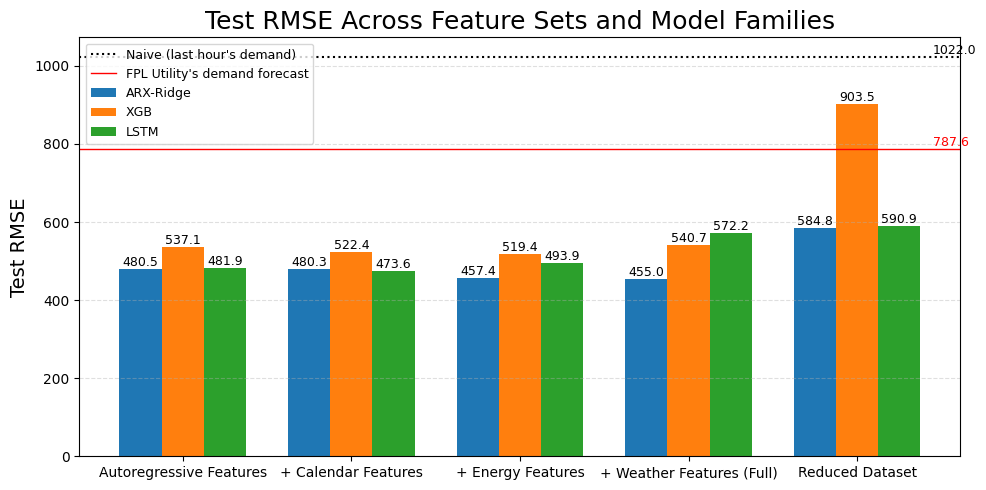

In [11]:
# Grouped bar chart for the best ARX-Ridge, GBM, and LSTM models for each of five feature sets.

fig, ax = plt.subplots(figsize=(10, 5))

MODEL_NAMES_AE = MODEL_NAMES[:5]
x = np.arange(len(MODEL_NAMES_AE))
width = 0.25

arx_vals  = rmse_df["ARX_Ridge"].loc[MODEL_NAMES_AE]
xgb_vals  = rmse_df["XGB"].loc[MODEL_NAMES_AE]
lstm_vals = rmse_df["LSTM"].loc[MODEL_NAMES_AE]

bars_arx  = ax.bar(x - width, arx_vals,  width, label="ARX-Ridge")
bars_xgb  = ax.bar(x,         xgb_vals,  width, label="XGB")
bars_lstm = ax.bar(x + width, lstm_vals, width, label="LSTM")

def add_value_labels(bars):
    for b in bars:
        height = b.get_height()
        ax.text(
            b.get_x() + b.get_width()/2,
            height,
            f"{height:.1f}",
            ha="center", va="bottom", fontsize=9
        )

add_value_labels(bars_arx)
add_value_labels(bars_xgb)
add_value_labels(bars_lstm)

naive_line = ax.axhline(
    naive_rmse, linestyle=":", linewidth=1.5, color='black',
    label="Naive (last hour's demand)"
)
forecast_line = ax.axhline(
    forecast_rmse, linewidth=1, color='r',
    label="FPL Utility's demand forecast"
)

ax.text(
    x[-1] + 0.45, naive_rmse,
    f"{naive_rmse:.1f}",
    color="black", fontsize=9, va="bottom"
)
ax.text(
    x[-1] + 0.45, forecast_rmse,
    f"{forecast_rmse:.1f}",
    color="r", fontsize=9, va="bottom"
)

ax.set_xticks(x)
ax.set_xticklabels([
    "Autoregressive Features",
    "+ Calendar Features",
    "+ Energy Features",
    "+ Weather Features (Full)",
    "Reduced Dataset",
])
ax.set_ylabel("Test RMSE", fontsize=14)
ax.set_title("Test RMSE Across Feature Sets and Model Families", fontsize=18)
ax.legend(loc="upper left", fontsize=9, frameon=True)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("figures/RMSEs", bbox_inches='tight')
plt.show()

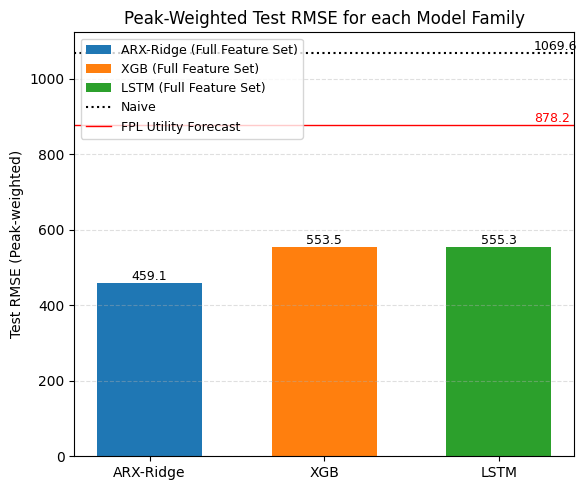

In [12]:
# Peak-Weighted evaluation for the best models on the full feature set.

fig, ax = plt.subplots(figsize=(6, 5))

model_family_labels = ["ARX-Ridge", "XGB", "LSTM"]
rmse_F_arx  = rmse_results["ARX_Ridge"]["model_F"]
rmse_F_xgb  = rmse_results["XGB"]["model_F"]
rmse_F_lstm = rmse_results["LSTM"]["model_F"]
rmse_vals = [rmse_F_arx, rmse_F_xgb, rmse_F_lstm]

x = np.arange(len(model_family_labels))
width = 0.6 

bars = ax.bar(
    x,
    rmse_vals,
    width,
    color=["C0", "C1", "C2"],
)

def add_value_labels_local(bars):
    for b in bars:
        height = b.get_height()
        ax.text(
            b.get_x() + b.get_width()/2,
            height,
            f"{height:.1f}",
            ha="center", va="bottom", fontsize=9
        )

add_value_labels_local(bars)

naive_line = ax.axhline(
    naive_rmse_peak, linestyle=":", linewidth=1.5, color='black',
    label="Naive (last hour's demand)"
)
forecast_line = ax.axhline(
    forecast_rmse_peak, linewidth=1, color='r',
    label="FPL Utility's demand forecast"
)

ax.text(
    x[-1] + 0.2, naive_rmse_peak,
    f"{naive_rmse_peak:.1f}",
    color="black", fontsize=9, va="bottom"
)
ax.text(
    x[-1] + 0.2, forecast_rmse_peak,
    f"{forecast_rmse_peak:.1f}",
    color="r", fontsize=9, va="bottom"
)

ax.set_xticks(x)
ax.set_xticklabels(model_family_labels)

ax.set_ylabel("Test RMSE (Peak-weighted)")
ax.set_title("Peak-Weighted Test RMSE for each Model Family")

handles = [
    bars[0], bars[1], bars[2],
    naive_line, forecast_line,
]
labels = [
    "ARX-Ridge (Full Feature Set)",
    "XGB (Full Feature Set)",
    "LSTM (Full Feature Set)",
    "Naive",
    "FPL Utility Forecast",
]

ax.legend(handles, labels, loc="upper left", fontsize=9, frameon=True)

ax.margins(x=0.05)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.savefig("figures/WeightedRMSEs", bbox_inches='tight')
plt.show()


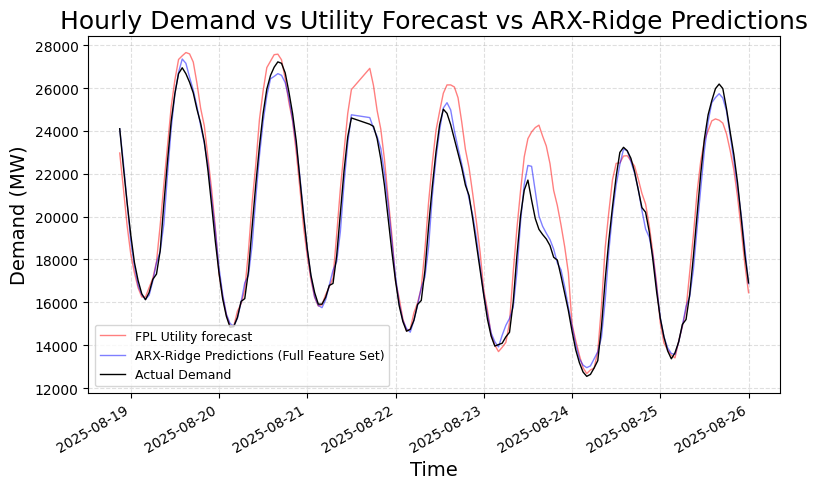

In [13]:
# Plot of actual demand over the last week of test data
#  compared against the utility operator forecast and
#  and our best ARX-Ridge model.

model_name = "model_D" 

meta_path  = arx_root / f"{model_name}_ridge_meta.json"
model_path = arx_root / f"{model_name}_ridge_best.joblib"

with open(meta_path, "r") as f:
    meta = json.load(f)

feature_cols = meta["feature_cols"]
target_col   = meta.get("target_col", TARGET_COL)

arx_model = joblib.load(model_path)

X_test = DFtest[feature_cols]
y_pred_arx = arx_model.predict(X_test)

DFtest_plot = DFtest.copy()
DFtest_plot["ARX_Ridge_pred"] = y_pred_arx

time_col = "t"

N_hours = 24 * 7
DF_zoom = DFtest_plot.tail(N_hours)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    DF_zoom[time_col],
    DF_zoom["Demand forecast"],
    label="FPL Utility forecast",
    linewidth=1,
    alpha=0.5,
    color="red",
)

ax.plot(
    DF_zoom[time_col],
    DF_zoom["ARX_Ridge_pred"],
    label="ARX-Ridge Predictions (Full Feature Set)",
    linewidth=1,
    alpha=0.5,
    color="blue",
)

ax.plot(
    DF_zoom[time_col],
    DF_zoom[target_col],
    label="Actual Demand",
    linewidth=1,
    color="black",
)

ax.set_xlabel("Time", fontsize=14)
ax.set_ylabel("Demand (MW)", fontsize=14)
ax.set_title("Hourly Demand vs Utility Forecast vs ARX-Ridge Predictions", fontsize=18)

ax.legend(loc="lower left", fontsize=9, frameon=True)

ax.grid(axis="both", linestyle="--", alpha=0.4)
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig("figures/DemandForecasts", bbox_inches='tight')
plt.show()
